# Анализ системы метрик приложения с развлекательным контентом: видео, подкастами и блогами.



### Данные



1. Датасет `ppro_visits.csv` — информация о посещениях приложения пользователями, которые зарегистрировались с 1 апреля 2024 года по 30 ноября 2024 года:
    - `user_id` — уникальный идентификатор пользователя;
    - `region` — страна пользователя;
    - `device` — категория устройства пользователя;
    - `channel` — идентификатор рекламного источника, из которого пришёл пользователь;
    - `session_start` — дата и время начала сессии;
    - `session_end` — дата и время окончания сессии.

2. Датасет `ppro_orders.csv` — информация о покупках:
    - `user_id` — уникальный идентификатор пользователя, который сделал покупку;
    - `event_dt` — дата и время покупки;
    - `revenue` — выручка.

3. Датасет `ppro_costs.csv` — информация о затратах на маркетинг:
    - `dt` — дата
    - `channel` — идентификатор рекламного источника;
    - `costs` — затраты на этот рекламный источник в этот день.
    
### План проекта
- Загрузить и предобработать данные.
- Подготовить данные для когортного анализа.
- Рассчитать и проанализировать метрики вовлечённости в продукт.
- Рассчитать и проанализировать финансовые метрики CAC, LTV и ROI за первые 28 дней с момента привлечения.
- Исследовать метрики в разрезе источника привлечения.
- Рассчитать период окупаемости маркетинговых вложений.
- Сформулировать выводы и рекомендации.


## Загрузка и предобработка данных


In [3]:
#импорт библиотек 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors
import numpy as np
# Создаём датафреймы для трёх таблиц
df_visits = pd.read_csv('https://code.s3.yandex.net/datasets/ppro_visits.csv')
df_orders = pd.read_csv('https://code.s3.yandex.net/datasets/ppro_orders.csv')
df_costs = pd.read_csv('https://code.s3.yandex.net/datasets/ppro_costs.csv')

In [4]:
#выгружаем информацию об исходных таблицах
dfs= [df_visits, df_orders, df_costs]
for df in dfs:
    display(df.info())
    print("-"*50)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161865 entries, 0 to 161864
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   user_id        161865 non-null  int64 
 1   region         161865 non-null  object
 2   device         161865 non-null  object
 3   channel        161865 non-null  object
 4   session_start  161865 non-null  object
 5   session_end    161865 non-null  object
dtypes: int64(1), object(5)
memory usage: 7.4+ MB


None

--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33893 entries, 0 to 33892
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   user_id   33893 non-null  int64  
 1   event_dt  33893 non-null  object 
 2   revenue   33893 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 794.5+ KB


None

--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 976 entries, 0 to 975
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   dt       976 non-null    object 
 1   channel  976 non-null    object 
 2   costs    976 non-null    float64
dtypes: float64(1), object(2)
memory usage: 23.0+ KB


None

--------------------------------------------------


<font color='blue'>
1. Отметим, что в датасете ppro_visits.csv наименование столбцов соответствует описанию. <br>
Количество столбцов - 6, количество строк - 161865. Данные полные без пропусков.<br>
Отметим, что столбцы session_start и session_end представлены типа object, далее тип необходимо будет изменить.<br>
2. Отметим, что в датасете ppro_orders.csv наименование столбцов соответствует описанию. <br>
Количество столбцов - 3, количество строк - 33893. Данные полные без пропусков.<br>
Отметим, что столбец event_dt представлен типа object, далее тип также необходимо будет изменить.<br>
3. Отметим, что в датасете ppro_costs.csv наименование столбцов соответствует описанию. <br>
Количество столбцов - 3, количество строк - 976. Данные полные без пропусков.<br>
Отметим, что столбец dt представлен типа object, далее тип также необходимо будет изменить.<br>

In [5]:
#выгружаем информацию о содержании таблиц
dfs = [
    ('df_visits', df_visits),
    ('df_orders', df_orders),
    ('df_costs', df_costs)
]
for name, df in dfs:
    print(f'Первые 5 строк датасета {name}: \n')
    display(df.head())
    print(f'Описательная статистика числовых столбцов {name} :\n')
    display(df.describe())
    print(f'Количество уникальных значений в столбцах {name} :\n')
    display(df.nunique())
    print("-"*50)
    

Первые 5 строк датасета df_visits: 



,user_id,region,device,channel,session_start,session_end
0,631105188566,India,desktop,MediaTornado,2024-04-01 03:48:00,2024-04-01 04:19:00
1,892885906464,India,tv,RocketSuperAds,2024-04-01 00:47:00,2024-04-01 01:14:00
2,517003690029,India,mobile,MediaTornado,2024-04-01 17:31:00,2024-04-01 17:53:00
3,185156659289,India,mobile,MediaTornado,2024-04-01 14:36:00,2024-04-01 14:51:00
4,409503040345,India,mobile,RocketSuperAds,2024-04-01 08:25:00,2024-04-01 08:45:00


Описательная статистика числовых столбцов df_visits :



,user_id
count,1.618650e+05
mean,4.991552e+11
std,2.884859e+11
min,2.603488e+07
25%,2.495467e+11
50%,4.984770e+11
75%,7.497252e+11
max,9.999755e+11


Количество уникальных значений в столбцах df_visits :



...

Описательная статистика числовых столбцов df_costs :



,costs
count,976.000000
mean,81.691910
std,70.237689
min,9.048984
25%,19.546203
50%,54.282076
75%,134.499067
max,316.923419


Количество уникальных значений в столбцах df_costs :



dt         244
channel      4
costs      833
dtype: int64

--------------------------------------------------


<div style="color: blue;">
1.Отметим информацию о том, что нет NaN ячеек у числовых данных.<br>
Отметим, что минимальная выручка с покупки отмечена 2.99, максимальная 29.99 <br>
Отметим, что минимальные затраты за один день по источнику 9.05, максимальные 316.92. <br>
2. В датасете df_visits представлена информация о 74856 уникальных пользователях из одной страны пользования, 3 видов категорий устройств и 4 идентификаторах рекламного источника.<br>
3. В датасете df_orders отметим информацию о 6889 уникальных покупателях и 5 видах выручки. Значит пользователи совершают покупки не разово.<br>
4. В датасете df_costs также представлена информация о 4 видах рекламных источников и 833 различных сумм затрат на рекламу.<br>

<div style="color: blue;">
    
    
  
#### Изменяем тип данных для столбцов с датой и временем



In [6]:
#для df_visits
df_visits['session_start'] =  pd.to_datetime(df_visits['session_start'])
df_visits['session_end'] = pd.to_datetime(df_visits['session_end'])
print(df_visits[['session_start', 'session_end']].dtypes)

session_start    datetime64[ns]
session_end      datetime64[ns]
dtype: object


In [7]:
#для df_orders
df_orders['event_dt'] = pd.to_datetime(df_orders['event_dt'])
print(df_orders['event_dt'].dtypes)

datetime64[ns]


In [8]:
#для df_costs
df_costs['dt']=pd.to_datetime(df_costs['dt'])
print(df_costs['dt'].dtypes)

datetime64[ns]


<div style="color: blue;">
    
    
  
#### Поиск дубликатов

In [9]:
#поиск явных дубликатов для всех датасетов
dfs = [
    ('df_visits', df_visits),
    ('df_orders', df_orders),
    ('df_costs', df_costs)
]
for name, df in dfs:
    print(f'Количество дубликатов в датасете {name} : \n')
    display(df.duplicated(keep=False).sum())
    print("-"*50)

Количество дубликатов в датасете df_visits : 



0

--------------------------------------------------
Количество дубликатов в датасете df_orders : 



0

--------------------------------------------------
Количество дубликатов в датасете df_costs : 



0

--------------------------------------------------


<div style="color: blue;">
Отметим, что явных дубликатов не выявлено<br>

In [10]:
#поиск неявных дубликатов для пользователей и времени сессий
df_visits_duplicates = df_visits.duplicated(subset=['user_id', 'session_start']).sum()
print(f"Количество дубликатов по user_id и session_start в df_visits: {df_visits_duplicates}")


Количество дубликатов по user_id и session_start в df_visits: 0


<div style="color: blue;">
Отметим, что нет дубликатов по пользователям и их времени начале сессии <br>

In [11]:
notonechannel_users = df_visits.groupby('user_id')['channel'].nunique().sort_values(ascending=False)
print(notonechannel_users.head(10))

user_id
693217525109    4
960989984531    4
358394297019    4
214407809296    4
71397459964     3
718857252390    3
833213030557    3
379916060522    3
405641656726    3
474913917590    3
Name: channel, dtype: int64


<div style="color: blue;">
Отметим, что пользователи могли посещать приложение, прееходя с разных источников <br>

In [12]:
#просмотр одного пользователя
display(df_visits[df_visits['user_id'] == 693217525109])

,user_id,region,device,channel,session_start,session_end
4643,693217525109,India,tv,RocketSuperAds,2024-04-10 04:44:00,2024-04-10 05:03:00
4898,693217525109,India,desktop,RocketSuperAds,2024-04-11 10:34:00,2024-04-11 12:26:00
5335,693217525109,India,mobile,RocketSuperAds,2024-04-12 01:34:00,2024-04-12 02:32:00
6777,693217525109,India,mobile,FaceBoom,2024-04-15 02:43:00,2024-04-15 03:35:00
9232,693217525109,India,mobile,RocketSuperAds,2024-04-20 16:20:00,2024-04-20 16:25:00
13106,693217525109,India,mobile,RocketSuperAds,2024-04-28 21:28:00,2024-04-28 22:29:00
14673,693217525109,India,mobile,MediaTornado,2024-05-01 16:54:00,2024-05-01 17:04:00
27419,693217525109,India,mobile,RocketSuperAds,2024-05-23 09:29:00,2024-05-23 11:31:00
30930,693217525109,India,mobile,RocketSuperAds,2024-05-29 20:48:00,2024-05-29 21:12:00
46675,693217525109,India,mobile,RocketSuperAds,2024-06-26 07:11:00,2024-06-26 07:57:00


In [13]:
#поиск неявных дубликатов для пользователей и времени заказа
df_orders_duplicates = df_orders.duplicated(subset=['user_id', 'event_dt']).sum()
print(f"Количество дубликатов по user_id и event_dt в df_orders: {df_orders_duplicates}")


Количество дубликатов по user_id и event_dt в df_orders: 0


<div style="color: blue;">
Отметим, что нет дубликатов по пользователям и их времени дате и времени покупки <br>

In [14]:
#поиск неявных дубликатов по дате затрат на рекламу
df_costs_duplicates= df_costs.duplicated(subset=['dt', 'channel']).sum()
print(f"Количество дубликатов по dt и channel в df_costs: {df_costs_duplicates}")


Количество дубликатов по dt и channel в df_costs: 0


<div style="color: blue;">
Отметим, что нет больше одной траты на одного рекламного источника в один день 

## Подготовка данных к когортному анализу с учётом того, что будем изучать окупаемость привлечения пользователей за первые 28 дней.


In [15]:
# определяем дату первой сессии для каждого пользователя 
#находим первый канал привлечения
df_visits=df_visits.sort_values(by='session_start')
df_visits['first_dt'] = df_visits.groupby('user_id')['session_start'].transform('min')
df_visits['first_dt'] = df_visits['first_dt'].dt.normalize()
df_visits['first_channel']=df_visits.groupby('user_id')['channel'].transform('first')
print(df_visits.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 161865 entries, 297 to 161080
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   user_id        161865 non-null  int64         
 1   region         161865 non-null  object        
 2   device         161865 non-null  object        
 3   channel        161865 non-null  object        
 4   session_start  161865 non-null  datetime64[ns]
 5   session_end    161865 non-null  datetime64[ns]
 6   first_dt       161865 non-null  datetime64[ns]
 7   first_channel  161865 non-null  object        
dtypes: datetime64[ns](3), int64(1), object(4)
memory usage: 11.1+ MB
None


In [16]:
#расчет количества всех привлеченных пользователей по источникам каждый день
count_users_of_channel =df_visits.groupby(['first_channel', 'first_dt'])['user_id'].nunique().reset_index()
print(count_users_of_channel)

    first_channel   first_dt  user_id
0        FaceBoom 2024-04-01      133
1        FaceBoom 2024-04-02       94
2        FaceBoom 2024-04-03      133
3        FaceBoom 2024-04-04      105
4        FaceBoom 2024-04-05      110
..            ...        ...      ...
971        TipTop 2024-11-26       76
972        TipTop 2024-11-27       93
973        TipTop 2024-11-28       87
974        TipTop 2024-11-29       93
975        TipTop 2024-11-30       84

[976 rows x 3 columns]


In [17]:
#расчет стоимости привлечение пользователей из информации о затратах по источникам и дате оплаты за рекламу
df_costs_channel_sum = df_costs.groupby(['channel','dt'])['costs'].sum().reset_index()
print(df_costs_channel_sum)

      channel         dt       costs
0    FaceBoom 2024-04-01  124.938874
1    FaceBoom 2024-04-02   88.147779
2    FaceBoom 2024-04-03  120.779457
3    FaceBoom 2024-04-04   98.981253
4    FaceBoom 2024-04-05  109.044760
..        ...        ...         ...
971    TipTop 2024-11-26  216.741490
972    TipTop 2024-11-27  263.071019
973    TipTop 2024-11-28  252.638555
974    TipTop 2024-11-29  261.943208
975    TipTop 2024-11-30  240.604295

[976 rows x 3 columns]


<div style="color: blue;">
    
    
    
    
#### Подсчет ежедневного САС для всех привлеченных пользователей когорты по первому каналу в первый день

In [18]:
#объеденим всех привлеченнх пользоватлей и затраты на их привлечение
df_for_cac = pd.merge(df_costs_channel_sum, count_users_of_channel,  how='left', left_on=['channel', 'dt'], right_on=['first_channel', 'first_dt'])
# Считаем CAC
df_for_cac['cac'] = df_for_cac['costs'] / df_for_cac['user_id']
print(df_for_cac)

      channel         dt       costs first_channel   first_dt  user_id  \
0    FaceBoom 2024-04-01  124.938874      FaceBoom 2024-04-01      133   
1    FaceBoom 2024-04-02   88.147779      FaceBoom 2024-04-02       94   
2    FaceBoom 2024-04-03  120.779457      FaceBoom 2024-04-03      133   
3    FaceBoom 2024-04-04   98.981253      FaceBoom 2024-04-04      105   
4    FaceBoom 2024-04-05  109.044760      FaceBoom 2024-04-05      110   
..        ...        ...         ...           ...        ...      ...   
971    TipTop 2024-11-26  216.741490        TipTop 2024-11-26       76   
972    TipTop 2024-11-27  263.071019        TipTop 2024-11-27       93   
973    TipTop 2024-11-28  252.638555        TipTop 2024-11-28       87   
974    TipTop 2024-11-29  261.943208        TipTop 2024-11-29       93   
975    TipTop 2024-11-30  240.604295        TipTop 2024-11-30       84   

          cac  
0    0.939390  
1    0.937742  
2    0.908116  
3    0.942679  
4    0.991316  
..        ...  

In [19]:
#добавляем в таблицу profiles данные сас
profiles = df_visits.groupby('user_id').agg({
    'first_dt': 'first',
    'first_channel': 'first'
}).reset_index()

profiles = pd.merge(profiles, df_for_cac, left_on=['first_channel', 'first_dt'], right_on=['channel', 'dt'], how='left')
display(profiles)
profiles = profiles[['user_id_x', 'first_dt_x', 'first_channel_x', 'cac']].rename(
    columns={'user_id_x': 'user_id', 'first_dt_x': 'first_dt', 'first_channel_x': 'first_channel'})

,user_id_x,first_dt_x,first_channel_x,channel,dt,costs,first_channel_y,first_dt_y,user_id_y,cac
0,26034876,2024-05-29,FaceBoom,FaceBoom,2024-05-29,85.792484,FaceBoom,2024-05-29,90,0.953250
1,69890364,2024-06-28,RocketSuperAds,RocketSuperAds,2024-06-28,36.295000,RocketSuperAds,2024-06-28,60,0.604917
2,75610104,2024-06-09,FaceBoom,FaceBoom,2024-06-09,120.812103,FaceBoom,2024-06-09,101,1.196159
3,76692397,2024-10-21,FaceBoom,FaceBoom,2024-10-21,138.903998,FaceBoom,2024-10-21,121,1.147967
4,80224421,2024-06-21,FaceBoom,FaceBoom,2024-06-21,148.704623,FaceBoom,2024-06-21,123,1.208981
...,...,...,...,...,...,...,...,...,...,...
74851,999956504962,2024-07-04,MediaTornado,MediaTornado,2024-07-04,18.699009,MediaTornado,2024-07-04,70,0.267129
74852,999959994517,2024-06-03,RocketSuperAds,RocketSuperAds,2024-06-03,34.850000,RocketSuperAds,2024-06-03,42,0.829762
74853,999962248443,2024-10-27,RocketSuperAds,RocketSuperAds,2024-10-27,25.075000,RocketSuperAds,2024-10-27,61,0.411066
74854,999970372492,2024-08-07,TipTop,TipTop,2024-08-07,185.095960,TipTop,2024-08-07,88,2.103363


In [20]:
print(f'Полученная таблица profiles: ')
display(profiles)

Полученная таблица profiles: 


,user_id,first_dt,first_channel,cac
0,26034876,2024-05-29,FaceBoom,0.953250
1,69890364,2024-06-28,RocketSuperAds,0.604917
2,75610104,2024-06-09,FaceBoom,1.196159
3,76692397,2024-10-21,FaceBoom,1.147967
4,80224421,2024-06-21,FaceBoom,1.208981
...,...,...,...,...
74851,999956504962,2024-07-04,MediaTornado,0.267129
74852,999959994517,2024-06-03,RocketSuperAds,0.829762
74853,999962248443,2024-10-27,RocketSuperAds,0.411066
74854,999970372492,2024-08-07,TipTop,2.103363


In [21]:
#добавляем в датасет с покупками информацию profile чтобы далее рассчитать lifetime до покупки
df_orders = pd.merge(df_orders, profiles[['user_id', 'first_dt', 'first_channel']], on=['user_id'], how='left')
display(df_orders.sample(10))
df_orders.info()

,user_id,event_dt,revenue,first_dt,first_channel
21295,30686139030,2024-09-30 05:49:44,2.99,2024-06-29,TipTop
19962,485971627765,2024-09-22 05:15:04,2.99,2024-09-15,RocketSuperAds
21856,134660454140,2024-10-03 00:24:23,2.99,2024-07-04,TipTop
11497,213770834281,2024-07-31 20:39:18,4.49,2024-07-14,RocketSuperAds
13944,705261401623,2024-08-16 05:38:30,2.99,2024-08-09,RocketSuperAds
3000,80184545481,2024-05-17 18:20:55,2.99,2024-05-09,TipTop
5945,778925830502,2024-06-16 04:05:33,4.49,2024-06-05,TipTop
19894,768250231824,2024-09-22 07:30:01,2.99,2024-08-01,RocketSuperAds
2022,653448091420,2024-05-05 09:21:16,2.99,2024-05-05,TipTop
7960,324395117096,2024-07-04 03:04:49,4.49,2024-07-02,TipTop


<class 'pandas.core.frame.DataFrame'>
Int64Index: 33893 entries, 0 to 33892
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   user_id        33893 non-null  int64         
 1   event_dt       33893 non-null  datetime64[ns]
 2   revenue        33893 non-null  float64       
 3   first_dt       33893 non-null  datetime64[ns]
 4   first_channel  33893 non-null  object        
dtypes: datetime64[ns](2), float64(1), int64(1), object(1)
memory usage: 1.6+ MB


In [22]:
#рассчет lifetime для покупок
df_orders['lifetime_before_order'] = (df_orders['event_dt'] - df_orders['first_dt']).dt.days
df_orders['lifetime_before_order'] = df_orders['lifetime_before_order'].astype(int)
#проверка
display(df_orders.sort_values(by='lifetime_before_order', ascending=False).head(10))
print(df_orders.info())

,user_id,event_dt,revenue,first_dt,first_channel,lifetime_before_order
33647,238793124843,2024-11-30 08:41:41,2.99,2024-04-02,RocketSuperAds,242
33648,218790167319,2024-11-30 12:48:47,2.99,2024-04-03,MediaTornado,241
33404,289870437321,2024-11-29 21:38:24,2.99,2024-04-02,RocketSuperAds,241
33405,809981895899,2024-11-29 21:18:32,2.99,2024-04-03,TipTop,240
33183,233829774683,2024-11-28 05:55:18,2.99,2024-04-02,RocketSuperAds,240
32527,114720579655,2024-11-25 01:45:20,2.99,2024-04-01,RocketSuperAds,238
33184,282336748354,2024-11-28 21:41:17,2.99,2024-04-04,RocketSuperAds,238
33406,886796218513,2024-11-29 04:59:16,4.49,2024-04-05,TipTop,238
32954,169488618933,2024-11-27 02:38:28,2.99,2024-04-05,RocketSuperAds,236
32298,233829774683,2024-11-24 20:51:27,2.99,2024-04-02,RocketSuperAds,236


<class 'pandas.core.frame.DataFrame'>
Int64Index: 33893 entries, 0 to 33892
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   user_id                33893 non-null  int64         
 1   event_dt               33893 non-null  datetime64[ns]
 2   revenue                33893 non-null  float64       
 3   first_dt               33893 non-null  datetime64[ns]
 4   first_channel          33893 non-null  object        
 5   lifetime_before_order  33893 non-null  int64         
dtypes: datetime64[ns](2), float64(1), int64(2), object(1)
memory usage: 1.8+ MB
None


In [23]:
df_visits['lifetime'] = (df_visits['session_start'] - df_visits['first_dt']).dt.days.astype('int')
#display(df_visits)

## Анализ месячной динамики основных метрик продукта

1. Анализ данных с изучения динамики активности пользователей и их вовлечённости в продукт. Рассчитываем по всем данным значения DAU, MAU и Stickiness и визуализируем их. Активными считаем всех пользователей, которые взаимодействовали с приложением.

2. В разрезе каждого месяца привлечения новых пользователей рассчитаем:
- Среднюю стоимость привлечения пользователя (CAC).
- Значение LTV и ROI с учётом покупок, совершённых за 28 дней с момента привлечения.

Здесь и далее при расчёте LTV и ROI учитываем всех привлечённых пользователей когорты.

Визуализируем метрики и сформулируем небольшой промежуточный вывод. Сделаем акцент на общей динамике изменения метрик с учётом появления нового контента в начале лета.

 <div style="color: blue;">
     
#### Задача 1

<div style="color: blue;">
Используем датасет df_visits для учета всех активных пользователей

<class 'pandas.core.frame.DataFrame'>
Int64Index: 161865 entries, 297 to 161080
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   user_id        161865 non-null  int64         
 1   region         161865 non-null  object        
 2   device         161865 non-null  object        
 3   channel        161865 non-null  object        
 4   session_start  161865 non-null  object        
 5   session_end    161865 non-null  datetime64[ns]
 6   first_dt       161865 non-null  datetime64[ns]
 7   first_channel  161865 non-null  object        
 8   lifetime       161865 non-null  int64         
dtypes: datetime64[ns](2), int64(2), object(5)
memory usage: 12.3+ MB
None


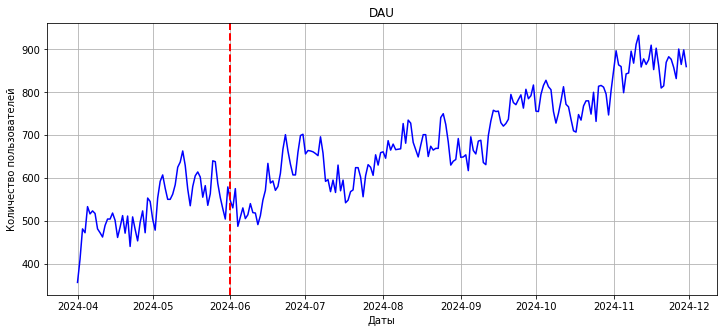

In [24]:
df_visits['session_start']=df_visits['session_start'].dt.date
df_DAU=df_visits.groupby(['session_start'])['user_id'].nunique().reset_index()
print(df_visits.info())
# строим график в matplotlib
plt.subplots(figsize=(12,5))
plt.plot(df_DAU['session_start'], df_DAU['user_id'], color='blue')
plt.axvline(x=pd.to_datetime('2024-06-01'), color='red', linestyle='--', linewidth=2)
plt.title('DAU')
plt.xlabel('Даты')
plt.ylabel('Количество пользователей')
plt.grid()
plt.show()

<div style="color: blue;">
Отметим диапазон активных пользователей от 300 до 1000 в течение представленных дат.<br>
Можем сказать, что наблюдается положительная динамика активных пользователей в течение года.<br>
Также отметим помимо, что наблюдается цикличная "просадка" метрики через месяц.

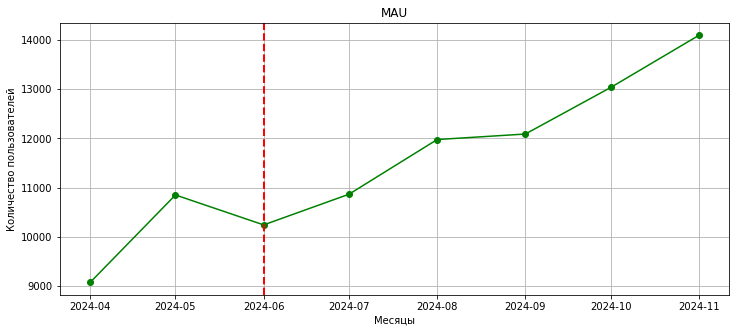

In [25]:
#выделяем месяц первой сессии из даты первой сессии
df_visits['session_start_month'] = pd.to_datetime(df_visits['session_start']).dt.to_period('M').dt.to_timestamp()
#агрегация данных по кагорте
df_MAU=df_visits.groupby(['session_start_month'])['user_id'].nunique().reset_index()
# строим график в matplotlib
plt.subplots(figsize=(12,5))
plt.plot(df_MAU['session_start_month'], df_MAU['user_id'], color='green', marker='o')
plt.axvline(x=pd.to_datetime('2024-06-01'), color='red', linestyle='--', linewidth=2)
plt.title('MAU')
plt.xlabel('Месяцы')
plt.ylabel('Количество пользователей')
plt.grid()
plt.show()

<div style="color: blue;">
Отметим положительную ежемесячную динамикуактивных пользователей.<br>
Также уточним, что в июне 2024 наблюдается "просадка", сравнивая с маем 2024.<br>
За 7 месяцев ежемесячное количество активных пользователей выросло с 9000 до 14000.

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8 entries, 0 to 7
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   session_start_month  8 non-null      datetime64[ns]
 1   user_id_x            8 non-null      int64         
 2   session_start        8 non-null      datetime64[ns]
 3   user_id_y            8 non-null      float64       
 4   stick                8 non-null      float64       
dtypes: datetime64[ns](2), float64(2), int64(1)
memory usage: 384.0 bytes
None


,session_start_month,user_id_x,session_start,user_id_y,stick
0,2024-04-01,9069,2024-04-01,488.333333,5.384644
1,2024-05-01,10849,2024-05-01,576.967742,5.318165
2,2024-06-01,10240,2024-06-01,580.366667,5.667643
3,2024-07-01,10864,2024-07-01,615.000000,5.660898
4,2024-08-01,11977,2024-08-01,681.193548,5.687514
5,2024-09-01,12089,2024-09-01,724.100000,5.989743
6,2024-10-01,13036,2024-10-01,773.193548,5.931218
7,2024-11-01,14097,2024-11-01,868.133333,6.158284


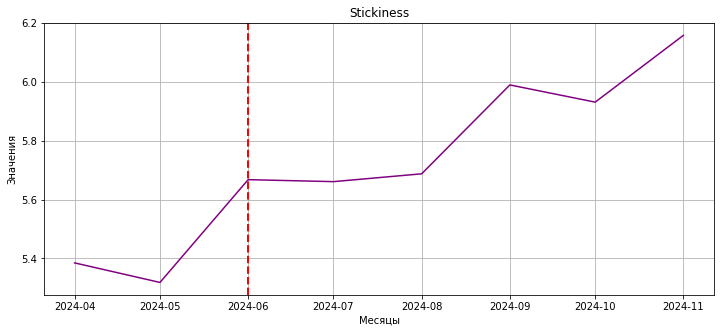

In [26]:
#рассчет среднемесячного DAU для каждого месяца
df_DAU['session_start'] = pd.to_datetime(df_DAU['session_start']).dt.to_period('M').dt.to_timestamp()
dau_monthly_average = df_DAU.groupby('session_start')['user_id'].mean().reset_index()
stickiness_table = df_MAU.merge(dau_monthly_average, left_on=['session_start_month'],right_on= ['session_start'])
stickiness_table['stick'] =stickiness_table['user_id_y']/stickiness_table['user_id_x'] *100
print(stickiness_table.info())
display(stickiness_table)
# строим график в matplotlib
plt.subplots(figsize=(12,5))

plt.plot(stickiness_table['session_start'], stickiness_table['stick'], color='purple')
plt.axvline(x=pd.to_datetime('2024-06-01'), color='red', linestyle='--', linewidth=2)
plt.title('Stickiness')
plt.xlabel('Месяцы')
plt.ylabel('Значения')
plt.grid()
plt.show()

<div style="color: blue;">
От 5 % до 6,5 % активных пользователей заходят в приложение ежедневно каждый месяц. <br>
Отметим общую положительную ежемесячную динамику доли активных пользователей в течение года, которые пользуются приложением ежедневно.<br>
Отметим, что небольшая "просадка" была в мае 2024 и октябре 2024.

 <div style="color: blue;">
     
#### Выводы по задаче 1

<div style="color: blue;">
Отметим, что показатели DAU и MAU имееют положительную динамику в течение 7 месяцев. Значит источники  привлекают пользователей.<br>
Несмотря на то, что в июне 2024 MAU "просела", среднемесячные DAU рос, что незначительно отразилось на Stickiness и показатель вырос в сравнении с маем 2024.

 <div style="color: blue;">
     
#### Задача 2

 <div style="color: blue;">
     
#### Расчет суммарных маркетингового бюджета по месяцам


In [27]:
#выделим месяц привлечение из даты первого привлечения в датасете с рекламной
df_costs['dt_month'] = pd.to_datetime(df_costs['dt']).dt.to_period('M').dt.to_timestamp()
#рассчитаем суммарные затраты на рекламу по месяцам
df_for_cac = df_costs.groupby('dt_month')['costs'].sum().reset_index()
print(df_for_cac)

    dt_month         costs
0 2024-04-01   6663.052333
1 2024-05-01   7327.775412
2 2024-06-01   8492.116887
3 2024-07-01   9217.078561
4 2024-08-01  10999.013650
5 2024-09-01  10838.014747
6 2024-10-01  12595.403113
7 2024-11-01  13598.849128


 <div style="color: blue;">
     
#### Расчет привлеченных пользователей по месяцам привлечения

In [28]:
#выделим месяц привлечение из даты первого привлечения в датесете с событиями
df_visits['first_dt_month'] =df_visits['first_dt'].dt.to_period('M').dt.to_timestamp()
#считаем количество уникальных пользователей, привлеченных по месяцам
df_visits_count_users =df_visits.groupby('first_dt_month')['user_id'].nunique().reset_index()
print(df_visits_count_users)

  first_dt_month  user_id
0     2024-04-01     9069
1     2024-05-01     9789
2     2024-06-01     8719
3     2024-07-01     8742
4     2024-08-01     9518
5     2024-09-01     9198
6     2024-10-01     9520
7     2024-11-01    10301


 <div style="color: blue;">
     
#### Расчет средней стоимости привлечения пользователя (CAC) по месяцам

,dt_month,costs,first_dt_month,user_id,CAC
0,2024-04-01,6663.052333,2024-04-01,9069,0.734706
1,2024-05-01,7327.775412,2024-05-01,9789,0.748572
2,2024-06-01,8492.116887,2024-06-01,8719,0.973978
3,2024-07-01,9217.078561,2024-07-01,8742,1.054344
4,2024-08-01,10999.013650,2024-08-01,9518,1.155601
5,2024-09-01,10838.014747,2024-09-01,9198,1.178301
6,2024-10-01,12595.403113,2024-10-01,9520,1.323047


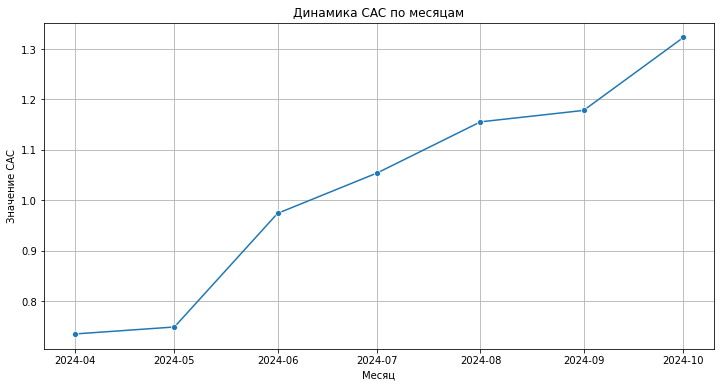

In [29]:
df_CAC = df_for_cac.merge(df_visits_count_users, left_on ='dt_month',right_on='first_dt_month', how='left')
#рассчитываем показатель САС
df_CAC['CAC'] = df_CAC['costs']/df_CAC['user_id']
df_CAC= df_CAC[df_CAC['first_dt_month'].dt.month != 11]
display(df_CAC)


plt.figure(figsize=(12, 6))

# Строим линейный график с разделением по типам трафика
sns.lineplot(
    data=df_CAC,
    x='first_dt_month',
    y='CAC',
    ci=False,
    marker='o',
)



# Добавляем подписи осей
plt.title('Динамика CAC по месяцам')

# Добавляем заголовок
plt.xlabel('Месяц')
plt.ylabel('Значение CAC')
plt.grid()
plt.show()

<div style="color: blue;">
Отметим стоимость привлечения одного клиента не превышала 1,35 за 7 месяцев.<br>
Наблюдаем рост метрики САС с июня 2024 после стабильного апреля и мая, но такде отметим рост суммарных затрат на привлечение и рост привлеченных пользователей

 <div style="color: blue;">
     
    
#### Расчет LTV

 <div style="color: blue;">
     
    
#### Поиск пользователей с покупками до 28 дней после привлечения

In [30]:
#выделим месяц даты привлечения в заказах
df_orders['first_dt_month'] = df_orders['first_dt'].dt.to_period('M').dt.to_timestamp()
#отфильтруем датасет с учётом покупок, совершённых за 28 дней с даты момента привлечения
df_orders_for_28 = df_orders[df_orders['lifetime_before_order'] <=28 ]
print(df_orders_for_28.info())
display(df_orders_for_28.sample(5))

<class 'pandas.core.frame.DataFrame'>
Int64Index: 21664 entries, 0 to 33892
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   user_id                21664 non-null  int64         
 1   event_dt               21664 non-null  datetime64[ns]
 2   revenue                21664 non-null  float64       
 3   first_dt               21664 non-null  datetime64[ns]
 4   first_channel          21664 non-null  object        
 5   lifetime_before_order  21664 non-null  int64         
 6   first_dt_month         21664 non-null  datetime64[ns]
dtypes: datetime64[ns](3), float64(1), int64(2), object(1)
memory usage: 1.3+ MB
None


,user_id,event_dt,revenue,first_dt,first_channel,lifetime_before_order,first_dt_month
27183,305881709226,2024-10-30 02:08:07,2.99,2024-10-27,RocketSuperAds,3,2024-10-01
26296,265512798915,2024-10-26 11:46:20,2.99,2024-10-04,TipTop,22,2024-10-01
5823,20719102470,2024-06-15 18:43:45,2.99,2024-06-06,TipTop,9,2024-06-01
26315,154257891114,2024-10-26 15:11:03,2.99,2024-10-13,TipTop,13,2024-10-01
6464,365631030794,2024-06-21 21:27:15,2.99,2024-06-11,RocketSuperAds,10,2024-06-01


 <div style="color: blue;">
     
    
#### Поиск накопительного дохода по месяцам

In [31]:
# Суммируем доход по месяцам привлечения и периодам со дня привлечения
df_for_revenue_sum =df_orders_for_28.groupby(['first_dt_month'])['revenue'].sum().reset_index()
display(df_for_revenue_sum)

,first_dt_month,revenue
0,2024-04-01,7535.30
1,2024-05-01,8246.98
2,2024-06-01,7524.10
3,2024-07-01,10115.59
4,2024-08-01,10508.12
5,2024-09-01,10191.07
6,2024-10-01,11604.24
7,2024-11-01,8899.96


<div style="color: blue;">
Используя п 3.0.5  "Расчет привлеченных пользователей по месяцам привлечения" найдем LTV


 <div style="color: blue;">
     
    
#### Расчет LTV

In [32]:
df_LTV =pd.merge(df_visits_count_users, df_for_revenue_sum, on='first_dt_month', how='left')
display(df_LTV)
#считаем LTV как накопленный доход за период/ количество всех привлечённых пользователей когорты
df_LTV['LTV_28'] =df_LTV['revenue']/df_LTV['user_id']
df_LTV = df_LTV[df_LTV['first_dt_month'].dt.month != 11]
display(df_LTV)

,first_dt_month,user_id,revenue
0,2024-04-01,9069,7535.30
1,2024-05-01,9789,8246.98
2,2024-06-01,8719,7524.10
3,2024-07-01,8742,10115.59
4,2024-08-01,9518,10508.12
5,2024-09-01,9198,10191.07
6,2024-10-01,9520,11604.24
7,2024-11-01,10301,8899.96


,first_dt_month,user_id,revenue,LTV_28
0,2024-04-01,9069,7535.30,0.830885
1,2024-05-01,9789,8246.98,0.842474
2,2024-06-01,8719,7524.10,0.862954
3,2024-07-01,8742,10115.59,1.157125
4,2024-08-01,9518,10508.12,1.104026
5,2024-09-01,9198,10191.07,1.107966
6,2024-10-01,9520,11604.24,1.218933


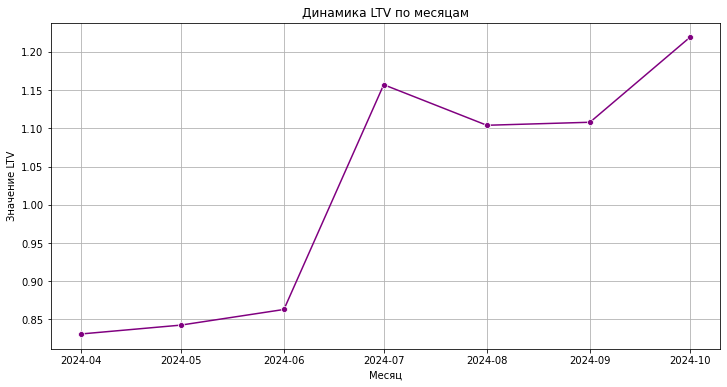

In [33]:
plt.figure(figsize=(12, 6))
#Строим линейный график с разделением по типам трафика
sns.lineplot(
    data=df_LTV,
    x='first_dt_month',
    y='LTV_28',
    ci=False,
    marker='o',
    color='purple'
)


# Добавляем подписи осей
plt.title('Динамика LTV по месяцам')

# Добавляем заголовок
plt.xlabel('Месяц')
plt.ylabel('Значение LTV')
plt.grid()
plt.show()

<div style="color: blue;">
1. Согласно заданию, с учетом того, что мы учитывали всех привлеченных пользователей когорт, значение прибыли за одного пользователя в месяц находится в диапазоне от 0.8 до 1.3 .<br> 
2. Отметим, после появления нового контента в начале лета резкий скачок LTV в июле 2024 года.Почти неизменным осталось количество привлеченных пользователей, в то время, как накопительный доход в этом месяцев вырос относительно июня, следовательно пользователи стали больше покупать.<br>
3. Наблюдаем резкий упадок LTV В ноябре, несмотря на растующее количество привлеченных пользователей, показатель LTV "просел" из-за уменьшение суммарного накопленного дохода за месяц

 <div style="color: blue;">
     
    
#### Расчет ROI

,first_dt_month,CAC,LTV_28,ROI
0,2024-04-01,0.734706,0.830885,13.090812
1,2024-05-01,0.748572,0.842474,12.544115
2,2024-06-01,0.973978,0.862954,-11.399006
3,2024-07-01,1.054344,1.157125,9.748332
4,2024-08-01,1.155601,1.104026,-4.463070
5,2024-09-01,1.178301,1.107966,-5.969218
6,2024-10-01,1.323047,1.218933,-7.869245


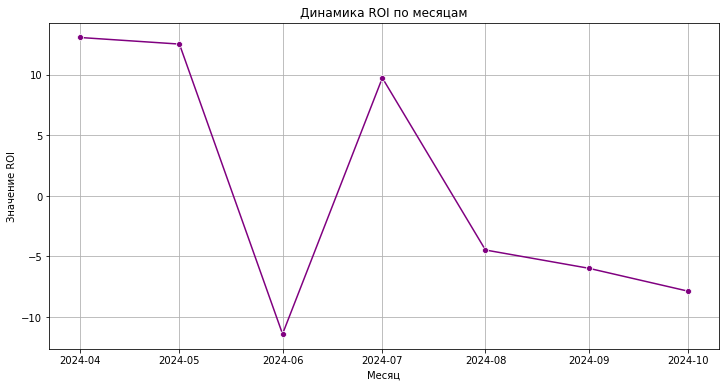

In [34]:
df_roi = pd.merge(df_CAC[['first_dt_month','CAC']], df_LTV[['first_dt_month','LTV_28']], on='first_dt_month')
df_roi['ROI'] =(df_roi['LTV_28']- df_roi['CAC'])/df_roi['CAC'] *100
df_roi = df_roi[df_roi['first_dt_month'].dt.month != 11]
display(df_roi)
plt.figure(figsize=(12, 6))
#Строим линейный график с разделением по типам трафика
sns.lineplot(
    data=df_roi,
    x='first_dt_month',
    y='ROI',
   ci=False,
    marker='o',
    color='purple'
)


# Добавляем подписи осей
plt.title('Динамика ROI по месяцам')

# Добавляем заголовок
plt.xlabel('Месяц')
plt.ylabel('Значение ROI')
plt.grid()
plt.show()

<div style="color: blue;">
Выводы по задаче 2<br>
С учетом полученных результатов отметим, что:<br>
1. ROI имеет отрицательную динамику.<br>
2. В апреле, мае и июле рекламные затраты окупались, во всем остальные месяцы с июня наблюдаем невозврат инвестиций.<br>
3. Наименьший ROI зафиксирован в ноябре. С учетом одинокового количества привлеченных пользователей для CAC и LTV, можем говорить о том, что рекламные затраты превышают прибыль.

 <div style="color: blue;">
     
    
#### Выводы по анализу месячной динамики основных метрик продукта

<div style="color: blue;">
Положительная динамика DAU, MAU свидетельсвует об эффективности рекламных источников. 
С появлением нового контента видим положительный скачок накопительного дохода в июле 2024.<br>
Рост стоимости привлечения на одного пользователя параллелен с ростом привлеченных пользователей.<br>
Наблюдаем отрицательный возврат рекламных затрат.<br>

## Анализ метрик в разрезе источника привлечения
 1. Определим самые популярные источники привлечения:
- Посчитаем общее число привлечённых пользователей для каждого источника.
- Визуализируем динамику набора новых пользователей по дням в каждом источнике.
- Рассчитаем и визуализируем динамику DAU, MAU и Stickiness по источникам привлечения.

1. Изучим динамику изменения метрик на 28-й день в разрезе источника. Проведем анализ с выделением недельных когорт по дате привлечения. Рассчитаем и визуализируем:
- Скользящее удержание на 14-й день с момента привлечения (за период с 14-го по 28-й день).
- Конверсию в покупку.

Недельную динамику затрат на маркетинг по каждому источнику привлечения.
Динамику среднего CAC, значений LTV и ROI.

По результатам проведем анализ рекламных каналов. Закрепим общей характеристикой каждого рекламного канала по рассчитанным метрикам. Укажем, какие рекламные каналы не вышли на уровень окупаемости за ожидаемый период, и предположим почему.


 <div style="color: blue;">
     
    
#### Задача 1

 <div style="color: blue;">
     
    
##### Общее число привлечённых пользователей для каждого источника

In [35]:
#определим самые популярные источники по количеству привлеченных пользователей 
count_users_of_first_channel  = df_visits.groupby('first_channel')['user_id'].nunique()
#общее количество уникальных пользователей
total_users = count_users_of_first_channel.sum()
# процент для каждого канала
count_users_of_first_channel_percentage = (count_users_of_first_channel/total_users) * 100
count_users_of_first_channel = pd.DataFrame({
    'unique_users': count_users_of_first_channel,
    '%': count_users_of_first_channel_percentage
}).reset_index()
display(count_users_of_first_channel.style.format({'% от общего числа': '{:.2f}%'}).set_caption("Общее число привлеченных пользователей по каналам"))

,first_channel,unique_users,%
0,FaceBoom,28401,37.940846
1,MediaTornado,14080,18.809447
2,RocketSuperAds,14257,19.045901
3,TipTop,18118,24.203805


<div style="color: blue;">
Выделено 4 рекламных источника. <br>
Наибольшее число привлеченных пользователей у источника FaceBoom -38% пользователей<br>
Меньше привлекает источник MediaTornado - 19% пользователей

 <div style="color: blue;">
     
    
##### Динамика набора новых пользователей по дням в каждом источнике

,user_id,first_dt,first_channel,cac
0,26034876,2024-05-29,FaceBoom,0.953250
1,69890364,2024-06-28,RocketSuperAds,0.604917
2,75610104,2024-06-09,FaceBoom,1.196159
3,76692397,2024-10-21,FaceBoom,1.147967
4,80224421,2024-06-21,FaceBoom,1.208981
...,...,...,...,...
74851,999956504962,2024-07-04,MediaTornado,0.267129
74852,999959994517,2024-06-03,RocketSuperAds,0.829762
74853,999962248443,2024-10-27,RocketSuperAds,0.411066
74854,999970372492,2024-08-07,TipTop,2.103363


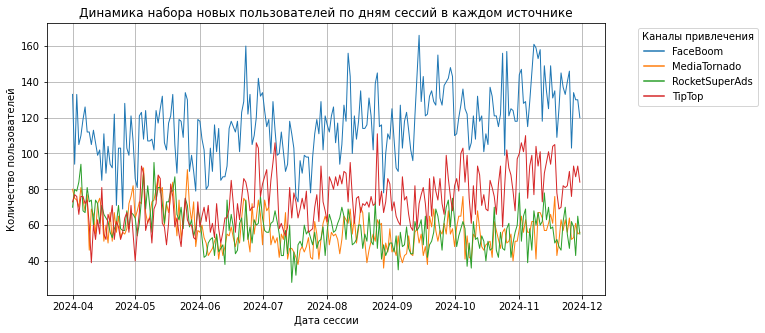

In [38]:
display(profiles)
# Динамика привлечения новых пользователей по источникам'
new_users_channel = profiles.groupby(['first_dt','first_channel'])['user_id'].nunique().reset_index()
plt.figure(figsize=(10, 5))
sns.lineplot(x='first_dt', y='user_id', data=new_users_channel, hue='first_channel', linewidth=1)
plt.title('Динамика набора новых пользователей по дням сессий в каждом источнике')
plt.xlabel('Дата сессии')
plt.ylabel('Количество пользователей')
plt.legend(title='Каналы привлечения', loc='upper left', bbox_to_anchor=(1.05, 1)) 
plt.grid()
plt.show()

<div style="color: blue;">
По всем источникам не заметны четкие циклы или закономерности. Количество пользователей динамично меняется ежедневно.<br>
1.Отметим, что по источнику FaceBoom диапазон новых пользователей находится выше остальных трех источников - по данному источнику больше уникальных пользователей ежедневно (встречается от 70 до 170 новых пользователей ежедневно).<br>
2.Отметим, что второе место занимает источник TipTop - его диапазон от 40 до 110 <br>
3.Конкурирующий минимум количества пользователей в день занимают источники MediaTornado и RocketSuperAds. Причем по источнику RocketSuperAdsдо июня число пользователей чаще можно увидеть выше 60, а после июня до 60 пользователей в день

 <div style="color: blue;">
        
##### Динамика DAU, MAU и Stickiness по источникам привлечения

 <div style="color: blue;">
        
##### Динамика DAU

In [39]:
#считаем количество пользователей по источникам ежедневно
df_DAU_first_channel = df_visits.groupby(['session_start', 'first_channel'])['user_id'].nunique().reset_index()

In [40]:
#посмотрим пограничные значения для каждого канала
min_max_for_first_channel = df_DAU_first_channel.groupby('first_channel')['user_id'].agg(['min', 'max']).reset_index()
print(min_max_for_first_channel)

    first_channel  min  max
0        FaceBoom   92  216
1    MediaTornado   80  171
2  RocketSuperAds   70  193
3          TipTop   73  420


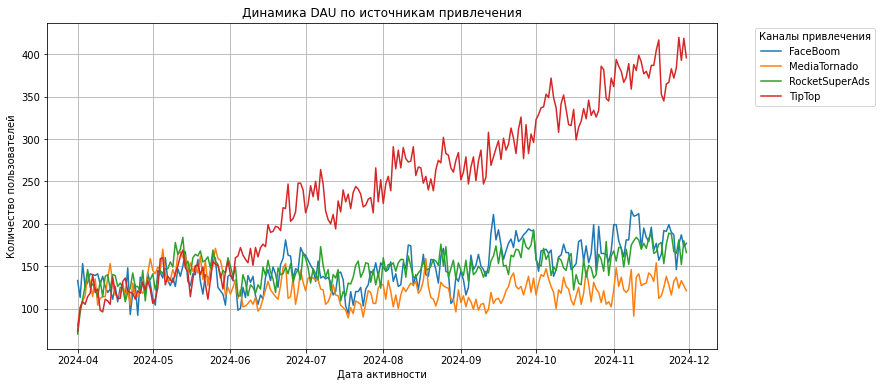

In [41]:
#визуализируем DAU по источникам
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_DAU_first_channel, x='session_start', y='user_id', hue='first_channel')
plt.title('Динамика DAU по источникам привлечения')
plt.xlabel('Дата активности')
plt.ylabel('Количество пользователей')
plt.legend(title='Каналы привлечения', loc='upper left', bbox_to_anchor=(1.05, 1)) 
plt.grid()
plt.show()

<div style="color: blue;">
1. Отметим информацию о том, что до июня 2024  по всем источникам ежедневное количество пользователей было в диапазоне от "менее 100" до "не более" 200.<br>
2. Начиная с июня 2024 заметна доминирующая динамика источника TipTop по количеству ежедневных пользователей - от 73 до 420 , в то время, как по другим источникам тоже наблюдается цикличная динамика, но без значительного числа привлеченных пользователей<br>
источник "MediaTornado" находится в диапазоне от 80 до 171<br>
источник "RocketSuperAds" находится в диапазоне от 70 до 193<br>
источник "FaceBoom" находится в диапазоне от 92 до 216.<br>
3. Для источника TipTop заметна цикличная динамика в пределах примерно полутора месяца в пределах 100-150 пользователей. Ежедневное количество пользователей за все месяцы возросло до "более 400" в положительной динамике.<br>
4. Меньше всего ежедневно наблюдаем пользователей, пришедших из источника MediaTornado на протяжении всего диапазона дат 2024 года.

 <div style="color: blue;">
        
##### Динамика MAU

,first_channel,min,max
0,FaceBoom,3170,4267
1,MediaTornado,1969,2546
2,RocketSuperAds,2030,2652
3,TipTop,1900,4933


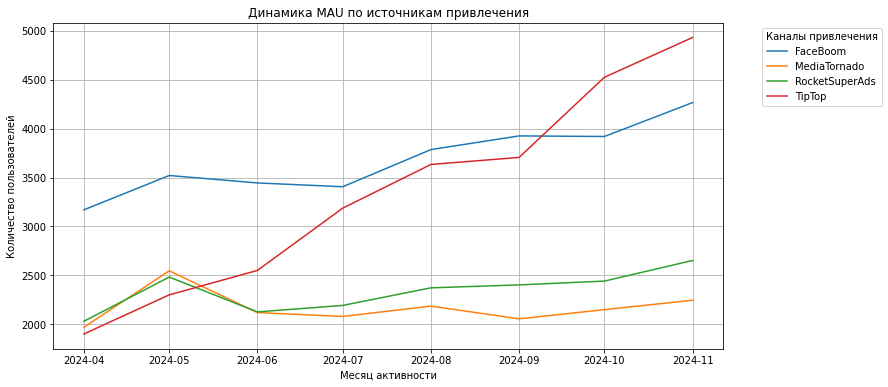

In [42]:
#агрегация данных по кагорте
df_MAU_for_first_channel =df_visits.groupby(['session_start_month', 'first_channel'])['user_id'].nunique().reset_index()
min_max_for_first_channel_month = df_MAU_for_first_channel.groupby('first_channel')['user_id'].agg(['min', 'max']).reset_index()
display(min_max_for_first_channel_month)
#визуализируем MAU по источникам
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_MAU_for_first_channel, x='session_start_month', y='user_id', hue='first_channel')
plt.title('Динамика MAU по источникам привлечения')
plt.xlabel('Месяц активности')
plt.ylabel('Количество пользователей')
plt.legend(title='Каналы привлечения', loc='upper left', bbox_to_anchor=(1.05, 1)) 
plt.grid()
plt.show()

<div style="color: blue;">
1. Отметим информацию о том, что изначально в апреле 2024 по каналу привлечения FaceBoom приходило больше пользоватей - больше 3000, в то время, как по другие трем каналам количество пользователей было около 2000.<br>
2. Начиная с июня 2024 отмечаем быстрый месячный рост ежемесячного посещения пользователей источника TipTop, в то время, как по источнику RocketSuperAds и MediaTornado отмечаем просадку с последующей стагнацией до ноября 2024<br>
3. По источнику FaceBoom также наблюдаем рост ежемесячного посещения в пределах 1100 пользователей за весь период.

 <div style="color: blue;">
        
##### Динамика Stickiness

In [43]:
#рассчет среднемесячного DAU для каждого месяца по источникам
df_DAU_first_channel['session_start_month'] = pd.to_datetime(df_DAU_first_channel['session_start']).dt.to_period('M').dt.to_timestamp()
dau_monthly_average_first_channel = df_DAU_first_channel.groupby(['session_start_month', 'first_channel'])['user_id'].mean().reset_index()
stickiness_table_first_channel = df_MAU_for_first_channel.merge(dau_monthly_average_first_channel, on=['session_start_month', 'first_channel'])
stickiness_table_first_channel['stick'] =stickiness_table_first_channel['user_id_y']/stickiness_table_first_channel['user_id_x'] *100

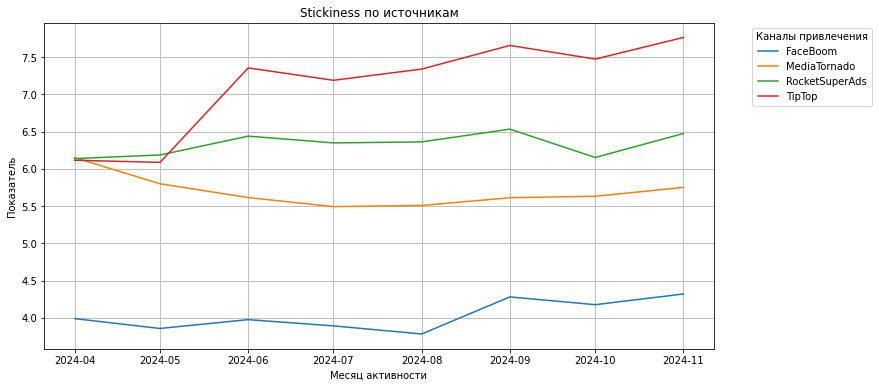

In [44]:
#строим график
plt.figure(figsize=(12, 6))
sns.lineplot(data=stickiness_table_first_channel, x='session_start_month', y='stick', hue='first_channel')
plt.title('Stickiness по источникам')
plt.xlabel('Месяц активности')
plt.ylabel('Показатель')
plt.legend(title='Каналы привлечения', loc='upper left', bbox_to_anchor=(1.05, 1)) 
plt.grid()
plt.show()

<div style="color: blue;">
Исходя из полученных результатов метрики Stickiness отметим:<br>
1. Пользователи, привлеченные по каналу FaceBoom меньше всего "залипают" в приложении. Их показатель можно назвать стабильно низким, относительно трех других каналов.<br>   
2. В июне наибольшее увеличение доли ежедневно посещающих приложение пользователей у источника TiTop, также отметим, что Stickiness растет до конца всего периода. Отметим, что небольшая "просадка" была в июле 2024 и октябре 2024.<br>
3. Стабильной с июня можем назвать Stickiness у источника RocketSuperAds<br>
4. Отметим отрицательную динамику у источника MediaTornado с начала периода данных.


 <div style="color: blue;">
        
##### Расчет скользящего Ratation на 14 и 28 день

In [57]:
# Оставляем события, совершенные в первые 28 дней
visits_28days = df_visits[df_visits['lifetime'] < 28].copy()
#display(visits_28days)
# Выделяем неделю первого посещения
visits_28days['interval'] = visits_28days['first_dt'].dt.to_period('W').dt.to_timestamp()
#display(visits_28days)
# Считаем размер когорт на первый день (количество уникальных пользователей по источнику привлечения по неделям в день привлечения)
visits_28days_first_day = (visits_28days
                       .query('lifetime == 0')
                       .groupby(['first_channel','interval'])
                       .agg(total_users = ('user_id','nunique')).reset_index()
                      )
#display(visits_28days_first_day)
# Считаем размер когорт на 14й и последующие дни (количество пользователей по источнику привлечения по неделям в дни после 14 дня со дня привлечения)
visits_28days_n_days = (visits_28days
                       .query('lifetime >= 13')
                       .groupby(['first_channel','interval'])
                       .agg(n_days_users = ('user_id','nunique')).reset_index()
                      )
#display(visits_28days_n_days)
# Соединяем данные и считаем скользящее удержание
rr = visits_28days_first_day.merge(visits_28days_n_days, on=['first_channel','interval'], how='left').fillna(0)
rr['rr_14'] = rr['n_days_users'] / rr['total_users']  
display(rr)

,first_channel,interval,total_users,n_days_users,rr_14
0,FaceBoom,2024-04-01,820,10.0,0.012195
1,FaceBoom,2024-04-08,749,11.0,0.014686
2,FaceBoom,2024-04-15,697,13.0,0.018651
3,FaceBoom,2024-04-22,676,10.0,0.014793
4,FaceBoom,2024-04-29,747,13.0,0.017403
...,...,...,...,...,...
135,TipTop,2024-10-28,639,181.0,0.283255
136,TipTop,2024-11-04,651,171.0,0.262673
137,TipTop,2024-11-11,657,83.0,0.126332
138,TipTop,2024-11-18,567,0.0,0.000000


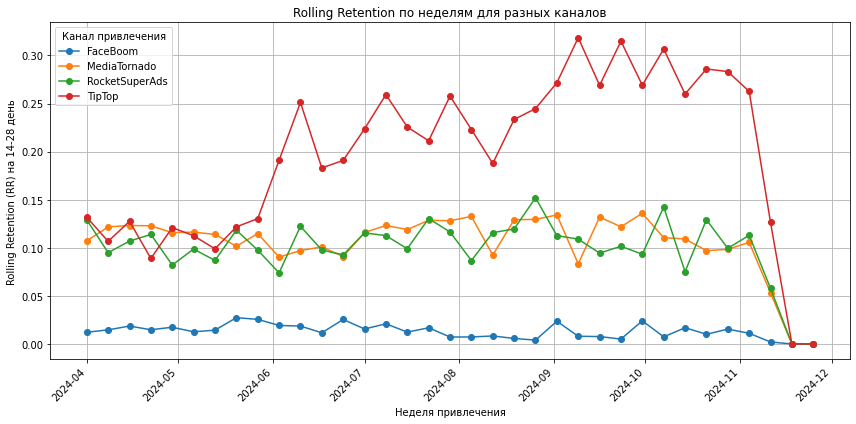

In [58]:
channels = rr['first_channel'].unique()

# Создаем график для каждого канала
plt.figure(figsize=(12, 6))  

for channel in channels:
    channel_data = rr[rr['first_channel'] == channel]
    plt.plot(channel_data['interval'], channel_data['rr_14'], marker='o', label=channel) 

plt.xlabel('Неделя привлечения')  
plt.ylabel('Rolling Retention (RR) на 14-28 день')
plt.title('Rolling Retention по неделям для разных каналов') 
plt.grid()  
plt.legend(title='Канал привлечения') 
plt.xticks(rotation=45, ha='right') 
plt.tight_layout()  
plt.show()

<div style="color: blue;">
Исходя из полученных результатов метрики скользщего удержания с 14 по 28 день отметим:<br>
1. Пользователи, привлеченные по каналу FaceBoom меньше всего активны в приложении с 14 по 28 день в течении всего периода с апреля по ноябрь. Их показатель можно назвать стабильно низким, относительно трех других каналов (RR меньше 0.05)<br>   
2. Конкурирующие "средние" каналы MediaTornado и RocketSuperAds в диапазоне от 0.07 до 0.15 возвращающихся пользователей. Рост после июньского обновления заметен только в первую неделю, к середине июня метрика снимажется.<br>
3. Источник TipTop заметно вырос по числу возвращающихся пользователей после июня относительно начала периода с апреля. Имел просадки на 0.25, но в целоом имеет положительную динамику. Максимальное значение, которое можно наблюдать - сентябрь -более 30% вернувшихся

 <div style="color: blue;">
        
##### Расчет конверсии в покупку на 28 день по источникам

In [59]:
# Оставляем покупки, совершенные в первые 28 дней
orders_28days = df_orders[df_orders['lifetime_before_order'] < 28]
# Определим, являлся ли пользователь покупателем
profiles['payer'] = profiles['user_id'].isin(orders_28days['user_id'].unique())

# Считаем конверсию
cr = profiles.copy()
cr['interval'] = cr['first_dt'].dt.to_period('W').dt.to_timestamp()
cr = cr.groupby(['first_channel','interval']).agg(cr = ('payer','mean')).reset_index()   
display(cr)

,first_channel,interval,cr
0,FaceBoom,2024-04-01,0.113415
1,FaceBoom,2024-04-08,0.104139
2,FaceBoom,2024-04-15,0.126255
3,FaceBoom,2024-04-22,0.107988
4,FaceBoom,2024-04-29,0.119143
...,...,...,...
135,TipTop,2024-10-28,0.125196
136,TipTop,2024-11-04,0.147465
137,TipTop,2024-11-11,0.118721
138,TipTop,2024-11-18,0.148148


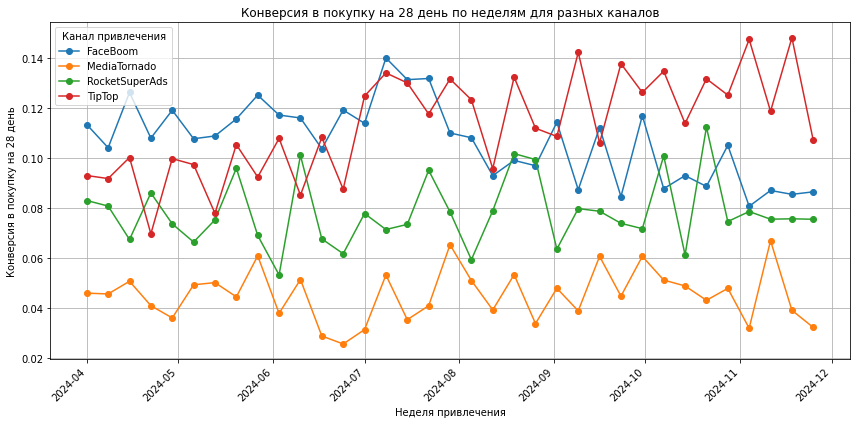

In [60]:
channels = cr['first_channel'].unique()

# Создаем график для каждого канала
plt.figure(figsize=(12, 6))  

for channel in channels:
    channel_data = cr[cr['first_channel'] == channel]
    plt.plot(channel_data['interval'], channel_data['cr'], marker='o', label=channel) 

plt.xlabel('Неделя привлечения')  
plt.ylabel('Конверсия в покупку на 28 день')
plt.title('Конверсия в покупку на 28 день по неделям для разных каналов') 
plt.grid()  
plt.legend(title='Канал привлечения') 
plt.xticks(rotation=45, ha='right') 
plt.tight_layout()  
plt.show()

<div style="color: blue;">
Исходя из полученных результатов метрики конверсии в покупку на 28 день отметим:<br>
1. Пользователи, привлеченные по каналу MediaTornado меньше всех совершают покупки на 28 день со дня привлечения в течении всего периода с апреля по ноябрь. Их показатель можно назвать стабильно низким, относительно трех других каналов (CR меньше 0.07)<br>   
2. Средним оказался источник RocketSuperAds в диапазоне от менее 0.06 до 0.12 пользователей, совершивших покупку на 28 день. Рост метрики после июньского обновления заметен только в первую неделю, к середине июня метрика снимажется. И также скачкообразна по всем неделям привлечения<br>
3. Изначально CR источника FaceBoom в начале периода с апреля по середину июня был выше (10% до 13% покупающих пользователей). Далее в июне-июля наблюдается конкуренция. Далее CR источника FaceBoom идет скачкообразно на спад. То время, как CR источника TipTop также циклична, но стремится вверх к 15% покупалей на 28 день.
 

 <div style="color: blue;">
        
##### Расчет недельной динамики затрат на маркетинг по каждому источнику привлечения. 

In [61]:
#выделяем неделю в датасете о затратах на рекламу и агригируем затраты
df_costs['week_of_costs'] = df_costs['dt'].dt.to_period('W').dt.to_timestamp()
df_for_weekly_costs = df_costs.groupby(['week_of_costs', 'channel'])['costs'].sum().reset_index()
display(df_for_weekly_costs)

,week_of_costs,channel,costs
0,2024-04-01,FaceBoom,769.875901
1,2024-04-01,MediaTornado,129.318322
2,2024-04-01,RocketSuperAds,466.650000
3,2024-04-01,TipTop,393.989381
4,2024-04-08,FaceBoom,698.872741
...,...,...,...
135,2024-11-18,TipTop,1627.048850
136,2024-11-25,FaceBoom,872.983777
137,2024-11-25,MediaTornado,88.593183
138,2024-11-25,RocketSuperAds,138.125000


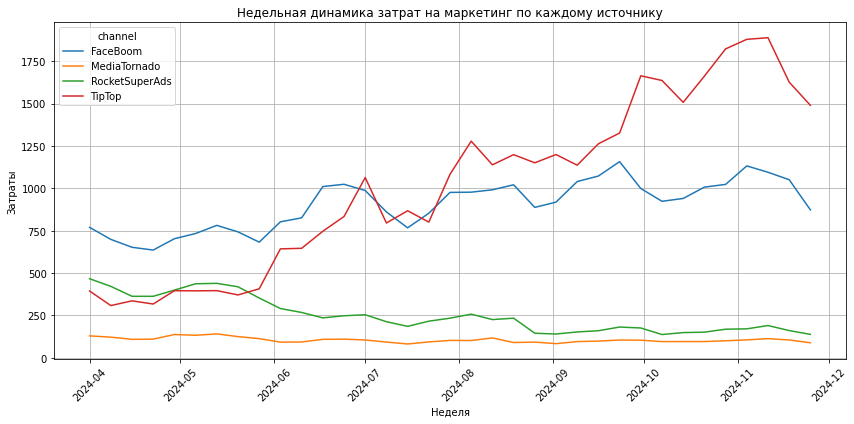

In [62]:
# Визуализация динамики затрат
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_for_weekly_costs, x='week_of_costs', y='costs', hue='channel')
plt.title('Недельная динамика затрат на маркетинг по каждому источнику')
plt.xlabel('Неделя')
plt.ylabel('Затраты')
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

<div style="color: blue;">
С учетом полученного результата расчет недельной динамики затрат на маркетинг по каждому источнику привлечения, отметим:<br>
1. Стабильными недельными затратами по источникам можно назвать источник MediaTornado, но и самый низкий - менее 250 стаильно.<br>
2. Затраты по источнику RocketSuperAds с июня уменьшаются и также "уходят" к менее 250<br>
3. Изначально в апреле самым затратным источниом был FaceBoom. Диапазон его недельных затрат в пределах всего периода от 650 до 1150 периодически наблюдатся просадки и поднятие затрат без закономерности.<br>
4. Самым затратным для компании приложения является источник TipTop, который начал стремительно расти по затратам после июня 2024. Также имеет просадки, но "набирает" быстрее.<br>
5. К концу года - ноябрь все затраты идут на спад.

 <div style="color: blue;">
        
##### Расчет динамики среднего CAC, значений LTV и ROI.

In [63]:
#Считаем средний CAC

In [64]:
df_costs

,dt,channel,costs,dt_month,week_of_costs
0,2024-04-01,FaceBoom,124.938874,2024-04-01,2024-04-01
1,2024-04-02,FaceBoom,88.147779,2024-04-01,2024-04-01
2,2024-04-03,FaceBoom,120.779457,2024-04-01,2024-04-01
3,2024-04-04,FaceBoom,98.981253,2024-04-01,2024-04-01
4,2024-04-05,FaceBoom,109.044760,2024-04-01,2024-04-01
...,...,...,...,...,...
971,2024-11-26,TipTop,216.741490,2024-11-01,2024-11-25
972,2024-11-27,TipTop,263.071019,2024-11-01,2024-11-25
973,2024-11-28,TipTop,252.638555,2024-11-01,2024-11-25
974,2024-11-29,TipTop,261.943208,2024-11-01,2024-11-25


In [65]:
#считаем суммарные затраты по неделям привлечения
df_costs_for_cac= df_costs[df_costs['dt'].dt.month != 11]
df_for_costs = df_costs_for_cac.groupby(['week_of_costs', 'channel'])['costs'].sum().reset_index()
display(df_for_costs)

,week_of_costs,channel,costs
0,2024-04-01,FaceBoom,769.875901
1,2024-04-01,MediaTornado,129.318322
2,2024-04-01,RocketSuperAds,466.650000
3,2024-04-01,TipTop,393.989381
4,2024-04-08,FaceBoom,698.872741
...,...,...,...
119,2024-10-21,TipTop,1662.445517
120,2024-10-28,FaceBoom,543.431929
121,2024-10-28,MediaTornado,53.571526
122,2024-10-28,RocketSuperAds,87.125000


In [66]:
#выделяем неделю привлечения для событий
df_visits_for_cac= df_visits[df_visits['first_dt'].dt.month != 11]
df_visits_for_cac['week_of_first_dt']=df_visits_for_cac['first_dt'].dt.to_period('W').dt.to_timestamp()

#рассчет количества пользователей по неделям привлечения
df_count_users_first_visit_channel = df_visits_for_cac.groupby(['week_of_first_dt', 'first_channel'])['user_id'].nunique().reset_index()
display(df_count_users_first_visit_channel)

/tmp/ipykernel_377/118374613.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_visits_for_cac['week_of_first_dt']=df_visits_for_cac['first_dt'].dt.to_period('W').dt.to_timestamp()


,week_of_first_dt,first_channel,user_id
0,2024-04-01,FaceBoom,820
1,2024-04-01,MediaTornado,522
2,2024-04-01,RocketSuperAds,542
3,2024-04-01,TipTop,516
4,2024-04-08,FaceBoom,749
...,...,...,...
119,2024-10-21,TipTop,577
120,2024-10-28,FaceBoom,485
121,2024-10-28,MediaTornado,197
122,2024-10-28,RocketSuperAds,208


In [67]:
#объединяем затраты на рекламу и привлеченных пользователей по неделям
df_of_cac = pd.merge(df_for_costs,df_count_users_first_visit_channel, left_on=['week_of_costs', 'channel'], right_on=['week_of_first_dt', 'first_channel'])
#рассчет САС
df_of_cac['cac']= df_of_cac['costs']/df_of_cac['user_id']
display(df_of_cac)

,week_of_costs,channel,costs,week_of_first_dt,first_channel,user_id,cac
0,2024-04-01,FaceBoom,769.875901,2024-04-01,FaceBoom,820,0.938873
1,2024-04-01,MediaTornado,129.318322,2024-04-01,MediaTornado,522,0.247736
2,2024-04-01,RocketSuperAds,466.650000,2024-04-01,RocketSuperAds,542,0.860978
3,2024-04-01,TipTop,393.989381,2024-04-01,TipTop,516,0.763545
4,2024-04-08,FaceBoom,698.872741,2024-04-08,FaceBoom,749,0.933074
...,...,...,...,...,...,...,...
119,2024-10-21,TipTop,1662.445517,2024-10-21,TipTop,577,2.881188
120,2024-10-28,FaceBoom,543.431929,2024-10-28,FaceBoom,485,1.120478
121,2024-10-28,MediaTornado,53.571526,2024-10-28,MediaTornado,197,0.271937
122,2024-10-28,RocketSuperAds,87.125000,2024-10-28,RocketSuperAds,208,0.418870


In [68]:
# Группируем данные по когорте
cac_grouped = df_of_cac.groupby(['week_of_first_dt', 'first_channel'])['cac'].mean().reset_index()

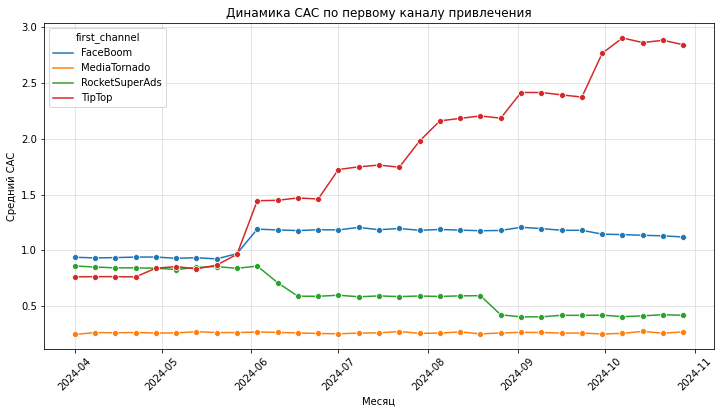

In [69]:
# Инициализируем холст для графика
plt.figure(figsize=(12, 6))

# Строим линейный график с разделением по типам трафика
sns.lineplot(
    data=df_of_cac,
    x='week_of_first_dt',
    y='cac',
    hue='first_channel',
    ci=False,
    marker='o',
)

# Настраиваем отображение подписей
plt.xticks(rotation=45)
plt.grid(alpha=.4)

# Добавляем подписи осей
plt.title('Динамика CAC по первому каналу привлечения')

# Добавляем заголовок
plt.xlabel('Месяц')
plt.ylabel('Средний CAC')
plt.show()

<div style="color: blue;">
С учетом полученного результата динамики средней стоимости привлечения пользователя по неделям, отметим:<br>
1. Стабильным можно назвать источник MediaTornado, но и самый низкий - менее 0,5 за весь период.<br>
2. Для других источников наблюдаем измененияс июня: <br>
    у TipTop скачкообразная положительная динамика в увеличении средней стоимости привлечения пользователя в неделю.<br>
    у FaceBoom CAC увеличился, но незначительно - на 0.25 и был стабилен до конца периода.<br>
    у RocketSuperAds после июня CAC упал до 0.5 и был стабилен до сентября, далее еще снизился на 0.25 и был стабилен до конца периода.

In [70]:
#считаем LTV
#датасет для заказов с первого по 28 день от дня привлечения df_orders_for_28 (использовали для расчет ltv по месяцам привлечения)
df_orders_for_28 = df_orders_for_28[df_orders_for_28['first_dt'].dt.month != 11]
df_orders_for_28['first_dt_week']=df_orders_for_28['first_dt'].dt.to_period('W').dt.to_timestamp()
#display(df_orders_for_28)

In [71]:
#считаем выручку по когорте и в день после привлечения
df_channel_revenue = df_orders_for_28.groupby(['first_dt_week', 'first_channel'])['revenue'].sum().reset_index()
display(df_channel_revenue)

,first_dt_week,first_channel,revenue
0,2024-04-01,FaceBoom,380.36
1,2024-04-01,MediaTornado,191.43
2,2024-04-01,RocketSuperAds,739.28
3,2024-04-01,TipTop,798.39
4,2024-04-08,FaceBoom,337.06
...,...,...,...
119,2024-10-21,TipTop,1542.11
120,2024-10-28,FaceBoom,270.68
121,2024-10-28,MediaTornado,129.12
122,2024-10-28,RocketSuperAds,262.79


In [73]:
#соединем датасеты 
df_for_ltv_cac = pd.merge(df_channel_revenue, df_of_cac, left_on=['first_dt_week', 'first_channel'], right_on=['week_of_first_dt', 'first_channel'],how='left')
#Считаем ltv на 28 день
df_for_ltv_cac['ltv'] = df_for_ltv_cac ['revenue'] / df_for_ltv_cac ['user_id']
#display(df_for_ltv_cac)
#расчет ROI
df_for_ltv_cac['roi'] = (df_for_ltv_cac ['ltv'] - df_for_ltv_cac ['cac'])/df_for_ltv_cac ['cac'] *100
#display(df_for_ltv_cac)

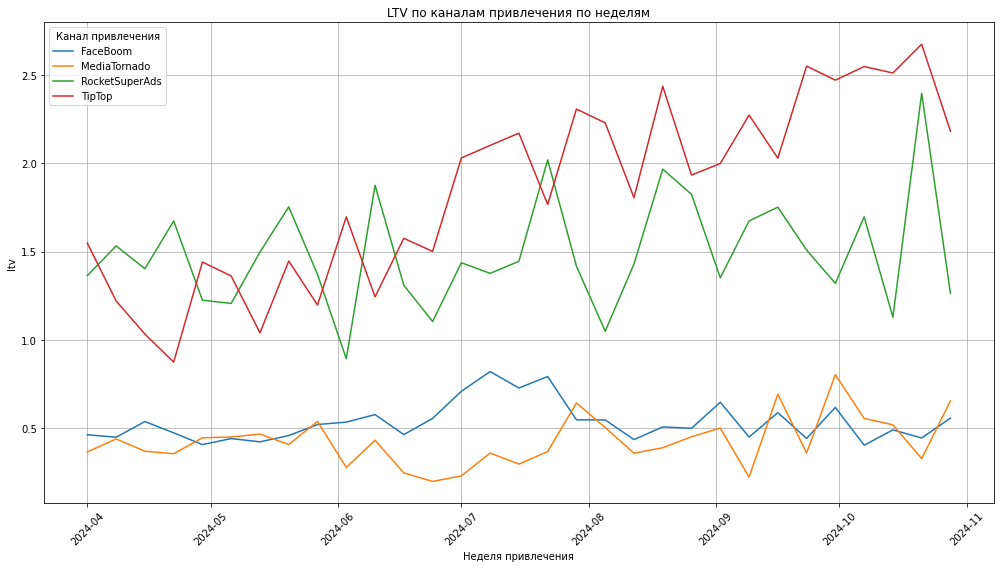

In [74]:
#Визуализация LTV
plt.figure(figsize=(14, 8))  
sns.lineplot(data=df_for_ltv_cac, x='first_dt_week', y='ltv', hue='first_channel')

plt.title('LTV по каналам привлечения по неделям')
plt.xlabel('Неделя привлечения')
plt.ylabel('ltv')
plt.xticks(rotation=45)  
plt.grid()  
plt.tight_layout() 
plt.legend(title='Канал привлечения') 

<div style="color: blue;">
По итогам полученного результата LTV отметим: <br>
1. Источники FaceBoom и MediaTornado относительно стабильны в доходе на одного пользователя за 28 дней. Метрика в диапазоне менее 0.5 до менее 1.<br>
2. у Источника RocketSuperAds цикличнообразная метрика LTV в диапазоне между 1 и 2 в течение всего периода. Наблюдается скачок в июне, но далее метрика "падает" до июля.<br>
3. у Источника TipTop отметим наибольший доход относительно всех источников. Заметим положительную динамику с начала июня и рост метрики дот конца периода. Этот источник оказался с прибыльными пользователями.


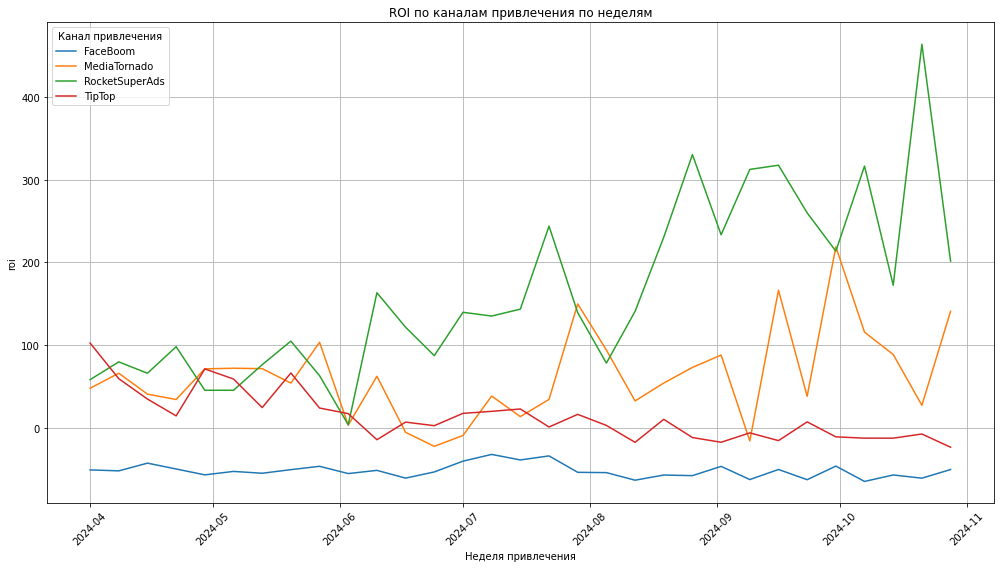

In [75]:
#Визуализация ROI
plt.figure(figsize=(14, 8))  
sns.lineplot(data=df_for_ltv_cac, x='first_dt_week', y='roi', hue='first_channel')

plt.title('ROI по каналам привлечения по неделям')
plt.xlabel('Неделя привлечения')
plt.ylabel('roi')
plt.xticks(rotation=45)  
plt.grid()  
plt.tight_layout()  
plt.legend(title='Канал привлечения') 


<div style="color: blue;">
Исходя из получившего графика значения окупаемости на 28 день отметим:<br>
1. Источника FaceBoom неокупаемый - значения ROI меньше 0 на протяжении всего периода  <br>
2. у Источника MediaTornado окупаемость по всем когортам, но есть небольшие просадки по окупаемости в последние 2 недели июня и в конце года<br>
3. Источник RocketSuperAds полностью окупаемый согласно графику по всем недельным когортам<br>
4. Источника TipTop с июня начинает терять окупаемость до конца периода, имеет тенденцию выхода в 0 с июня по октябрь. Далее уходит в минус.

 <div style="color: blue;">
        
##### Выводы по заданию 4

<div style="color: blue;">
Исходя из полученных результатов задания можем сделать предварительный вывод:<br>
1. По источнику FaceBoom:<br>
Лидирует по общему количеству привлеченных пользователей, особенно в начале периода. Однако, пользователи, привлеченные через этот канал, характеризуются низкой вовлеченностью (Stickiness) и низким процентом возврата для совершения покупок (конверсия на 28 день). Возможно приходит не целевая аудитория.<br>
Высокие и разные затраты на маркетинг, а также отрицательный ROI делает его неэффективным. <br>
2. По источнику TipTop:<br>
Демонстрирует самую сильную динамику развития в течение анализируемого периода. Начиная с июня, канал показывает быстрый рост ежемесячного посещения, увеличение доли ежедневно посещающих пользователей (Stickiness) и наибольшую динамику возврата пользователей на 14 день. Конверсия в покупку на 28 день низкая.<br> Несмотря на хороший рост привлечения и вовлеченности имеет ухудшение Roi после июня и перестает окупаться.  <br>
3. По источнику MediaTornado:<br>
Показывает самые слабые результаты по всем метрикам: наименьшее количество привлеченных пользователей, отрицательная динамика вовлеченности (Stickiness) и низкая конверсия. Однако, у этого канала стабильный процент возврата пользователей на 14 день, но малый.<br> Источник окупается. В размере всей прибыли, вклад незначителен.<br>
4. По источнику RocketSuperAds:<br>    
Привлекает среднее количество пользователей относительно других каналов,  вовлеченность (Stickiness) без явных изменений и  высокий процент возврата пользователей на 14 день. Однако конверсия в покупки на 28 день также очень низкая. <br> Канал полностью окупается. Снижение затрат на маркетинг после июня без потери эффективности (CAC снизился) дает больше уверенности относительно других. 
 

## Анализ периода окупаемости маркетинговых вложений

Для источников, которые к 28-му дню не выходят на уровень окупаемости, рассчитаем и визуализируем в виде тепловой карты значения ROI за больший период, например за 8–10 недель.

Разделим данные на недельные когорты по дате привлечения, в качестве интервала наблюдений используем недели.

Сделаем вывод о том, за какой период окупаются вложения в эти источники.

In [83]:

pp = df_orders.copy()

# Выделяем первую неделю привлечения
pp['first_week'] = pp['first_dt'].dt.to_period('W').dt.to_timestamp()

# Выделяем неделю покупки
pp['week'] = pp['event_dt'].dt.to_period('W').dt.to_timestamp()

# Рассчитаем разницу между минимальной датой и текущей датой в неделях
pp['N_week'] = (pp['week'] - pp['first_week']).dt.days / 7

# Суммируем revenue для каждой недели
pp = pp.groupby(['first_channel', 'first_week', 'N_week'])['revenue'].sum().reset_index()

# Отсортируем данные по N_week, для корректного расчета LTV при помощи cumsum()
pp = pp.sort_values(by=['first_channel', 'N_week'])

# Посчитаем кумулятивную выручку для каждой недели
pp['cum_revenue'] = pp.groupby(['first_channel','first_week'])['revenue'].cumsum()
# Считаем размер когорт
w_channel_cohort_size = profiles.copy()
w_channel_cohort_size['first_week'] = w_channel_cohort_size['first_dt'].dt.to_period('W').dt.to_timestamp()
#получаем количество пользователй и сас для когорты
w_channel_cohort_size = w_channel_cohort_size.groupby(['first_channel','first_week']).agg({'user_id':'nunique','cac':'mean'}).reset_index()
w_channel_cohort_size.columns = ['first_channel', 'first_week', 'total_users', 'cac']
# Добавим размер когорт и стоимость одного пользователя
pp = pp.merge(w_channel_cohort_size, on=['first_channel','first_week'])
pp['ltv'] = pp['cum_revenue'] / pp['total_users']
display(pp)
# Считаем ROI
pp['roi'] = (pp['ltv'] - pp['cac']) / pp['cac']

,first_channel,first_week,N_week,revenue,cum_revenue,total_users,cac,ltv
0,FaceBoom,2024-04-01,0.0,290.63,290.63,820,0.938873,0.354427
1,FaceBoom,2024-04-01,1.0,62.81,353.44,820,0.938873,0.431024
2,FaceBoom,2024-04-01,2.0,20.94,374.38,820,0.938873,0.456561
3,FaceBoom,2024-04-01,3.0,5.98,380.36,820,0.938873,0.463854
4,FaceBoom,2024-04-01,6.0,2.99,383.35,820,0.938873,0.467500
...,...,...,...,...,...,...,...,...
1973,TipTop,2024-11-11,1.0,460.67,952.80,657,2.875467,1.450228
1974,TipTop,2024-11-11,2.0,245.32,1198.12,657,2.875467,1.823623
1975,TipTop,2024-11-18,0.0,524.97,524.97,567,2.869575,0.925873
1976,TipTop,2024-11-18,1.0,355.52,880.49,567,2.869575,1.552892


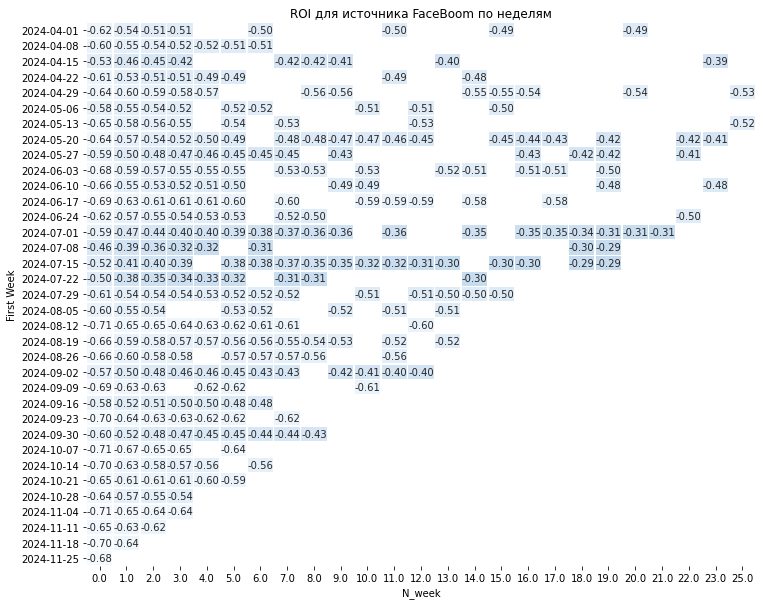

In [84]:
# Строим карту для FaceBoom
tiptop = pp.query('first_channel == "FaceBoom"').query('N_week < 26')

# Пивотируем данные, чтобы first_week были индексами, а N_week - столбцами
tiptop_pp = tiptop.pivot(index='first_week', columns='N_week', values='roi')
tiptop_pp.index = np.datetime_as_string(tiptop_pp.index, unit='D')

# Строим heatmap
plt.figure(figsize=(12, 10))

sns.heatmap(tiptop_pp,
        annot=True,
        fmt='.2f',
        linewidths=0.5, linecolor='white',
        vmax=1, cmap='Blues',
        cbar=False)

plt.title('ROI для источника FaceBoom по неделям')
plt.xlabel('N_week')
plt.ylabel('First Week')
plt.show()

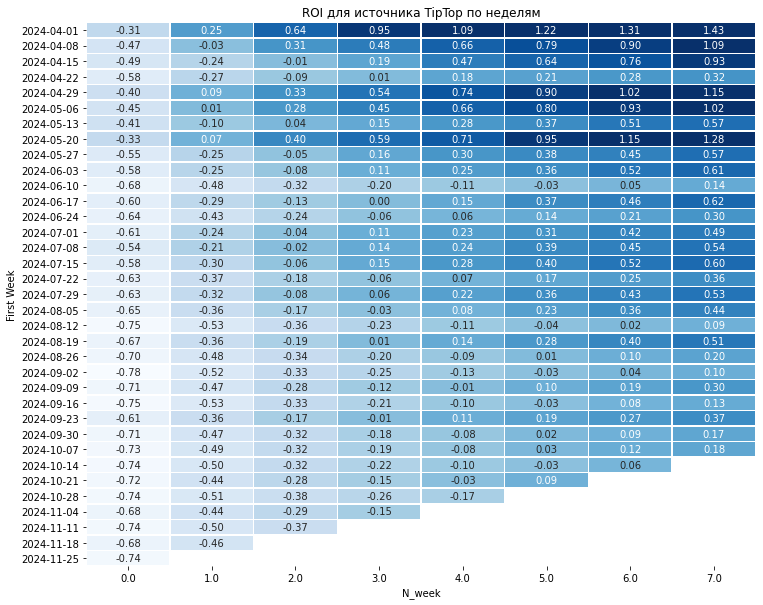

In [85]:
# Строим карту для FaceBoom
tiptop = pp.query('first_channel == "TipTop"').query('N_week < 8')

# Пивотируем данные, чтобы first_week были индексами, а N_week - столбцами
tiptop_pp = tiptop.pivot(index='first_week', columns='N_week', values='roi')
tiptop_pp.index = np.datetime_as_string(tiptop_pp.index, unit='D')

# Строим heatmap
plt.figure(figsize=(12, 10))

sns.heatmap(tiptop_pp,
        annot=True,
        fmt='.2f',
        linewidths=0.5, linecolor='white',
        vmax=1, cmap='Blues',
        cbar=False)

plt.title('ROI для источника TipTop по неделям')
plt.xlabel('N_week')
plt.ylabel('First Week')
plt.show()

 <div style="color: blue;">
        
##### Вывод по заданию 5

<div style="color: blue;">

Для источников FaceBoom и TipTop, которые к 28-му дню не выходят на уровень окупаемости, рассчитаны значения ROI за больший период - 8 недель.<br>
Судя, по полученной тепловой карте источника FaceBoom, наблюдаем отрицательные значения и спустя восьминедельный промежуток. На 8 недели источник не окупился ни по одной когорте. Увеличивая недели - периоды до 28, ROI в пределах периода до ноября не вышел в 0.<br>
Исходя из тепловой карты источника TipTop, на 7 неделю мы видим положительный ROI по всем недельным когортам - период, когда все привлеченные пользователи вернули своими тратами расходы приложения на рекламный источник.

## Выводы и рекомендации


<div style="color: blue;">
Приложение предлагает развлекательный контент для пользователй из Индии в период 8 месяцев для изучения. Пользователи приходили в приложение по 4м источникам привлечения.<br>
По изученным данным приложения с развлекательным контентом можем сказать:<br>
1. Основной проблемой стагнации выручки является низкая конверсия в покупку привлеченных пользователей в течение 28 дней по всем каналам привлечения.<br>
2. Несмотря на стагнацию выручки, у пользователй есть интерес к приложению и DAU, MAU показывают положительную динамику.<br>
3. Низкий монетезация пользователя. LTV достаточно низкий, как и конверсия в покупку.<br>
4. Низкое удержание пользователя. <br>
3. По итогам анализа рекламных источников:<br>
  FaceBoom:<br>    
  •  Имеет высокий объем привлеченных пользователей, особенно в начале периода.<br>
  •  Низкоеизкое удержание: на 14 день возвращается менее 3% пользователей, что является одним из худших показателей. Это в сочетании с изначально низкой вовлеченностью (Stickiness) и низкой конверсией на 28 день убедительно доказывает привлечение крайне нецелевой аудитории.<br>
  •  Окупаемость: Стабильный отрицательный ROI подтверждают, что привлеченные пользователи не приносят прибыли. <br>
  •  Инсайт: Канал является убыточным и неэффективным. <br>
 TipTop:<br>
  •  Имеет наилучшую динамику развития и отличное удержание: с летних когорт возвращаемость растет с 30% до впечатляющих 55% к осени. Также демонстрирует рост ежемесячных посещений и Stickiness., а также рост LTV.<br>
  •  Несмотря на феноменальное удержание и вовлеченность, конверсия в покупку на 28 день остается низкой.<br>
  •  Окупаемость: Скачкообразный рост CAC с июня приводит к снижению окупаемости. С июня по октябрь ROI стремится к 0, а затем уходит в минус.<br>
  •  Инсайт: Необходимопровести оптимизацию рекламных кампаний, чтобы снизить CAC и вернуть ROI в положительную зону. .<br>
  MediaTornado:<br>
  •  Имеет стабильное удержание: в среднем 10% пользователей возвращаются на 14 день.<br>
  •  Самые слабые результаты по большинству метрик: наименьшее количество привлеченных пользователей, отрицательная динамика вовлеченности (Stickiness) и низкая конверсия. Вклад в общую прибыль незначителен - низкий LTV.<br>
  •  Окупаемость: окупаем, но с просадками в течение 28 дней. <br>
  RocketSuperAds:<br>
  •  Привлекает среднее количество пользователей, демонстрирует стабильную вовлеченность и хорошее, стабильное удержание: от 13% до 30% возврата на 14 день. Канал полностью окупается, а снижение затрат на маркетинг после июня без потери эффективности (снижение CAC) делает его наиболее надежным.<br>
  •  Несмотря на положительные другие метрики, конверсия в покупки на 28 день очень низкая.<br>
  •  Окупаемость: Полностью окупается и демонстрирует наилучшую эффективность затрат.<br>
Ввод нового контента в июне оказал кратковременный положительный эффект на LTV. Более того, он привел к росту CAC основного канала привлечения (TipTop) и снижению его окупаемости.<br>
  Рекомендации:<br>
1. Обратить внимание на повышение LTV за счет улучшения монетизации и удержания пользователей.<br>
2. Сделать анализ для сегментации контента, выявить причиты низкого Retation. А также это может поспособствовать выделению топовой категории контента для будущей монетазации.<br>
3. Пересмотреть финансирование FaceBoom, так как источник убыточен, но привлекает новых пользователей. Сравнивая с другими тремя источниками, это был бы тот рекламный канал, от которого следовалао бы отказаться. <br>
4. Сохранять фокус на TipTop как на основном источнике роста по всем метрикам, но более внимательно следить за экономикой привлечения, так как просадка в затратах по источнику.<br>
5. Источник RocketSuperAds стабилен. Можно рассмотреть, как будущее вложение компании для развития.<br>
6. По сомнительному источнику MediaTornado также стоит принять решение о дальнейшем сотрудничестве: также стабилен, но не эффективен в привлечении новых пользователей. Окупаем, но приносит мало денег.